## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | DenseNet121 Production-ROI Robustness Ablation |
| Model / workflow | DenseNet-121/201 |
| Input | not reported |
| Loss | Cross-Entropy (CE) |
| Training / pipeline | Paired-view adaptation/evaluation |
| Result | single_cutout_control / epoch 1/30 / stage1 / QWK=0.2925 / F1=0.2516 / G1R=0.2484 / AP=0.2753 / selection=0.2753; single_cutout_control / epoch 2/30 / stage1 / QWK=0.3691 / F1=0.2140 / G1R=0.0915 / AP=0.3309 / selection=0.2968; single_cutout_control / epoch... |


# DenseNet121 Production-ROI Robustness Ablation

This validation-only experiment tests the remaining localization hypothesis after
the cutout ablation. Every arm uses the same DenseNet121, Kaggle split, CE loss,
full inverse-frequency sampler, three-stage schedule, natural orientation, and one
aggressive cutout. Only content-preserving ROI geometry and acquisition variation
change between arms.

| Arm | Geometry jitter | Acquisition variation |
| --- | --- | --- |
| `single_cutout_control` | none | none |
| `roi_geometry_jitter` | scale down and translate on the square canvas | none |
| `roi_geometry_plus_acquisition` | same geometry jitter | mild gamma, blur, and Gaussian noise |

Geometry jitter never crops image content. It simulates variable YOLO box placement
using black letterbox space while preserving marginal osteophytes. The test split is
not loaded. Promotion still requires a paired audit on exact production YOLO crops
and a newly locked labeled holdout.

In [1]:
import copy
import csv
import hashlib
import json
import os
import random
import shutil
import subprocess
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab; Drive mount skipped.')

try:
    import torch
    print('PyTorch:', torch.__version__)
except Exception as error:
    raise RuntimeError('Install PyTorch before running this notebook.') from error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

dataset_zip = '/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip'
dataset_root = '/content/Datasets/kaggle_knee_osteoarthritis'
if not os.path.isdir(dataset_root):
    if not os.path.isfile(dataset_zip):
        raise FileNotFoundError(
            f'Dataset ZIP not found at {dataset_zip}. Upload or mount the Kaggle '
            'dataset ZIP at this exact Drive path before running the notebook.'
        )
    os.makedirs('/content/Datasets', exist_ok=True)
    print(f'Extracting {dataset_zip} to /content/Datasets ...')
    subprocess.run(['unzip', '-q', '-o', dataset_zip, '-d', '/content/Datasets'], check=True)
if not os.path.isdir(dataset_root):
    raise FileNotFoundError(
        f'Extraction completed but {dataset_root} was not created. Check the ZIP layout.'
    )
print('Dataset ready:', dataset_root)

Mounted at /content/drive
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
Extracting /content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip to /content/Datasets ...
Dataset ready: /content/Datasets/kaggle_knee_osteoarthritis


## Fixed experiment configuration

The comparison changes only ROI/acquisition robustness. Checkpoint selection uses
QWK, macro F1, macro AP, and Grade-1 recall so a QWK gain cannot silently erase
Grade-1 sensitivity.

In [2]:
class TrainingConfig:
    dataset_root = '/content/Datasets/kaggle_knee_osteoarthritis'
    checkpoint_root = '/content/drive/MyDrive/Models/densenet121_checkpoints'
    run_timestamp = datetime.now(timezone.utc).strftime('%Y-%m-%d_%H-%M-%S_%f_UTC')
    run_root = os.path.join(checkpoint_root, f'{run_timestamp}_roi_robustness_ablation')

    model_name = 'densenet121'
    architecture = 'timm_densenet121_linear_gradcam'
    num_classes = 5
    pretrained = True
    image_size = 384
    batch_size = 64
    num_workers = 2
    seed = 42
    use_amp = True
    classifier_dropout = 0.20

    stage1_epochs = 5
    stage2_epochs = 15
    stage3_epochs = 10
    lr_warmup = 3e-4
    lr_coarse_backbone = 3e-5
    lr_coarse_head = 3e-4
    lr_finetune = 1e-5
    weight_decay = 1e-4

    sampler_power = 1.0
    selection_weights = {
        'qwk': 0.50,
        'macro_f1': 0.25,
        'macro_ap': 0.15,
        'grade1_recall': 0.10,
    }
    minimum_promotion_macro_f1 = 0.68
    minimum_promotion_grade1_recall = 0.48
    maximum_promotion_cam_failure_rate = 0.03

    # Audit every validation ROI; this anatomy gate is diagnostic only.
    cam_cases_per_grade = None
    min_joint_energy = 0.55
    max_border_energy = 0.25
    max_lower_tibia_energy = 0.25
    representative_passes_per_grade = 2
    misclassified_pairs_per_grade = 10

    arms = {
        'single_cutout_control': {
            'erasers': [(0.80, (0.02, 0.10))],
            'geometry_probability': 0.0,
            'geometry_scale': (1.0, 1.0),
            'gamma_probability': 0.0,
            'gamma_range': (1.0, 1.0),
            'blur_probability': 0.0,
            'noise_probability': 0.0,
            'noise_std': (0.0, 0.0),
        },
        'roi_geometry_jitter': {
            'erasers': [(0.80, (0.02, 0.10))],
            'geometry_probability': 0.80,
            'geometry_scale': (0.82, 0.98),
            'gamma_probability': 0.0,
            'gamma_range': (1.0, 1.0),
            'blur_probability': 0.0,
            'noise_probability': 0.0,
            'noise_std': (0.0, 0.0),
        },
        'roi_geometry_plus_acquisition': {
            'erasers': [(0.80, (0.02, 0.10))],
            'geometry_probability': 0.80,
            'geometry_scale': (0.82, 0.98),
            'gamma_probability': 0.25,
            'gamma_range': (0.90, 1.10),
            'blur_probability': 0.15,
            'noise_probability': 0.20,
            'noise_std': (0.005, 0.020),
        },
    }


os.makedirs(TrainingConfig.run_root, exist_ok=False)
print('Run directory:', TrainingConfig.run_root)
print(json.dumps(TrainingConfig.arms, indent=2))

Run directory: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-28_04-58-51_294354_UTC_roi_robustness_ablation
{
  "single_cutout_control": {
    "erasers": [
      [
        0.8,
        [
          0.02,
          0.1
        ]
      ]
    ],
    "geometry_probability": 0.0,
    "geometry_scale": [
      1.0,
      1.0
    ],
    "gamma_probability": 0.0,
    "gamma_range": [
      1.0,
      1.0
    ],
    "blur_probability": 0.0,
    "noise_probability": 0.0,
    "noise_std": [
      0.0,
      0.0
    ]
  },
  "roi_geometry_jitter": {
    "erasers": [
      [
        0.8,
        [
          0.02,
          0.1
        ]
      ]
    ],
    "geometry_probability": 0.8,
    "geometry_scale": [
      0.82,
      0.98
    ],
    "gamma_probability": 0.0,
    "gamma_range": [
      1.0,
      1.0
    ],
    "blur_probability": 0.0,
    "noise_probability": 0.0,
    "noise_std": [
      0.0,
      0.0
    ]
  },
  "roi_geometry_plus_acquisition": {
    "erasers": [
      [


## Dataset and content-preserving transforms

CLAHE 1.25, square padding, natural orientation, mild rotation and intensity
jitter, one aggressive cutout, and ImageNet normalization are shared. Geometry
jitter only scales down and repositions the complete ROI; it never crops anatomy.

In [3]:
class SquarePadOpenCV:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image, top, bottom, left, right,
            cv2.BORDER_CONSTANT, value=(0, 0, 0)
        )


class OpenCVCLAHE:
    def __call__(self, image_rgb):
        lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=1.25, tileGridSize=(8, 8))
        lightness = clahe.apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)), cv2.COLOR_LAB2RGB
        )



class ContentPreservingROIJitter:
    """Scale down and translate the complete square ROI without cropping it."""

    def __init__(self, probability, scale):
        self.probability = float(probability)
        self.scale = tuple(scale)

    def __call__(self, image):
        if random.random() >= self.probability:
            return image
        height, width = image.shape[:2]
        factor = random.uniform(*self.scale)
        resized_height = max(1, round(height * factor))
        resized_width = max(1, round(width * factor))
        resized = cv2.resize(
            image,
            (resized_width, resized_height),
            interpolation=cv2.INTER_AREA,
        )
        maximum_y = height - resized_height
        maximum_x = width - resized_width
        offset_y = random.randint(0, maximum_y) if maximum_y else 0
        offset_x = random.randint(0, maximum_x) if maximum_x else 0
        canvas = np.zeros_like(image)
        canvas[
            offset_y:offset_y + resized_height,
            offset_x:offset_x + resized_width,
        ] = resized
        return canvas


class RandomGammaCorrection:
    def __init__(self, probability, gamma_range):
        self.probability = float(probability)
        self.gamma_range = tuple(gamma_range)

    def __call__(self, image):
        if random.random() >= self.probability:
            return image
        gamma = random.uniform(*self.gamma_range)
        lookup = np.clip(
            255.0 * np.power(np.arange(256, dtype=np.float32) / 255.0, gamma),
            0,
            255,
        ).astype(np.uint8)
        return cv2.LUT(image, lookup)


class RandomGaussianNoise:
    def __init__(self, probability, standard_deviation):
        self.probability = float(probability)
        self.standard_deviation = tuple(standard_deviation)

    def __call__(self, tensor):
        if random.random() >= self.probability:
            return tensor
        sigma = random.uniform(*self.standard_deviation)
        return torch.clamp(tensor + torch.randn_like(tensor) * sigma, 0.0, 1.0)


class MultiRandomErasing:
    def __init__(self, erasers):
        self.erasers = [
            transforms.RandomErasing(
                p=probability,
                scale=scale,
                ratio=(0.5, 2.0),
                value=0,
            )
            for probability, scale in erasers
        ]

    def __call__(self, tensor):
        for eraser in self.erasers:
            tensor = eraser(tensor)
        return tensor


def get_transforms(arm_spec):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
    train_transform = transforms.Compose([
        OpenCVCLAHE(),
        SquarePadOpenCV(),
        ContentPreservingROIJitter(
            arm_spec['geometry_probability'], arm_spec['geometry_scale']
        ),
        RandomGammaCorrection(
            arm_spec['gamma_probability'], arm_spec['gamma_range']
        ),
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.50),
        transforms.RandomRotation(5, fill=0),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.0))
        ], p=arm_spec['blur_probability']),
        transforms.Resize((TrainingConfig.image_size, TrainingConfig.image_size)),
        transforms.ToTensor(),
        RandomGaussianNoise(
            arm_spec['noise_probability'], arm_spec['noise_std']
        ),
        MultiRandomErasing(arm_spec['erasers']),
        normalize,
    ])
    val_transform = transforms.Compose([
        OpenCVCLAHE(),
        SquarePadOpenCV(),
        transforms.ToPILImage(),
        transforms.Resize((TrainingConfig.image_size, TrainingConfig.image_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_transform, val_transform


def md5(path):
    digest = hashlib.md5()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


class KaggleDataset(Dataset):
    def __init__(self, root, split, transform=None, paths=None, labels=None):
        self.root = root
        self.transform = transform
        if paths is not None:
            self.image_paths = list(paths)
            self.labels = list(labels)
            return
        split_root = Path(root) / split
        self.image_paths, self.labels = [], []
        for class_dir in sorted(split_root.iterdir(), key=lambda path: int(path.name)):
            if not class_dir.is_dir() or not class_dir.name.isdigit():
                continue
            for path in sorted(class_dir.iterdir()):
                if path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
                    self.image_paths.append(str(path))
                    self.labels.append(int(class_dir.name))
        hashes = set()
        unique_paths, unique_labels = [], []
        for path, label in zip(self.image_paths, self.labels):
            image_hash = md5(path)
            if image_hash in hashes:
                continue
            hashes.add(image_hash)
            unique_paths.append(path)
            unique_labels.append(label)
        self.image_paths, self.labels = unique_paths, unique_labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = cv2.imread(self.image_paths[index])
        if image is None:
            raise IOError(f'Could not read {self.image_paths[index]}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)
        return image, self.labels[index]


if not os.path.isdir(TrainingConfig.dataset_root):
    raise FileNotFoundError(
        f"Dataset not found: {TrainingConfig.dataset_root}. "
        "Unzip kaggle_knee_osteoarthritis before running."
    )

base_train = KaggleDataset(TrainingConfig.dataset_root, 'train')
base_val = KaggleDataset(TrainingConfig.dataset_root, 'val')
train_paths, train_labels = base_train.image_paths, base_train.labels
val_paths, val_labels = base_val.image_paths, base_val.labels
print('Fixed split:', len(train_paths), 'train /', len(val_paths), 'validation')
print('Train classes:', dict(sorted(Counter(train_labels).items())))
print('Val classes:', dict(sorted(Counter(val_labels).items())))

class_counts = Counter(train_labels)
sample_weights = [1.0 / (class_counts[label] ** TrainingConfig.sampler_power) for label in train_labels]

Fixed split: 5778 train / 826 validation
Train classes: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Val classes: {0: 328, 1: 153, 2: 212, 3: 106, 4: 27}


## Verify augmentations before training

This preview is saved in the run directory. Inspect it before starting the long
training cell: anatomy must remain complete, black padding may move, and cutout
must be visible in most samples without consistently covering the joint line.

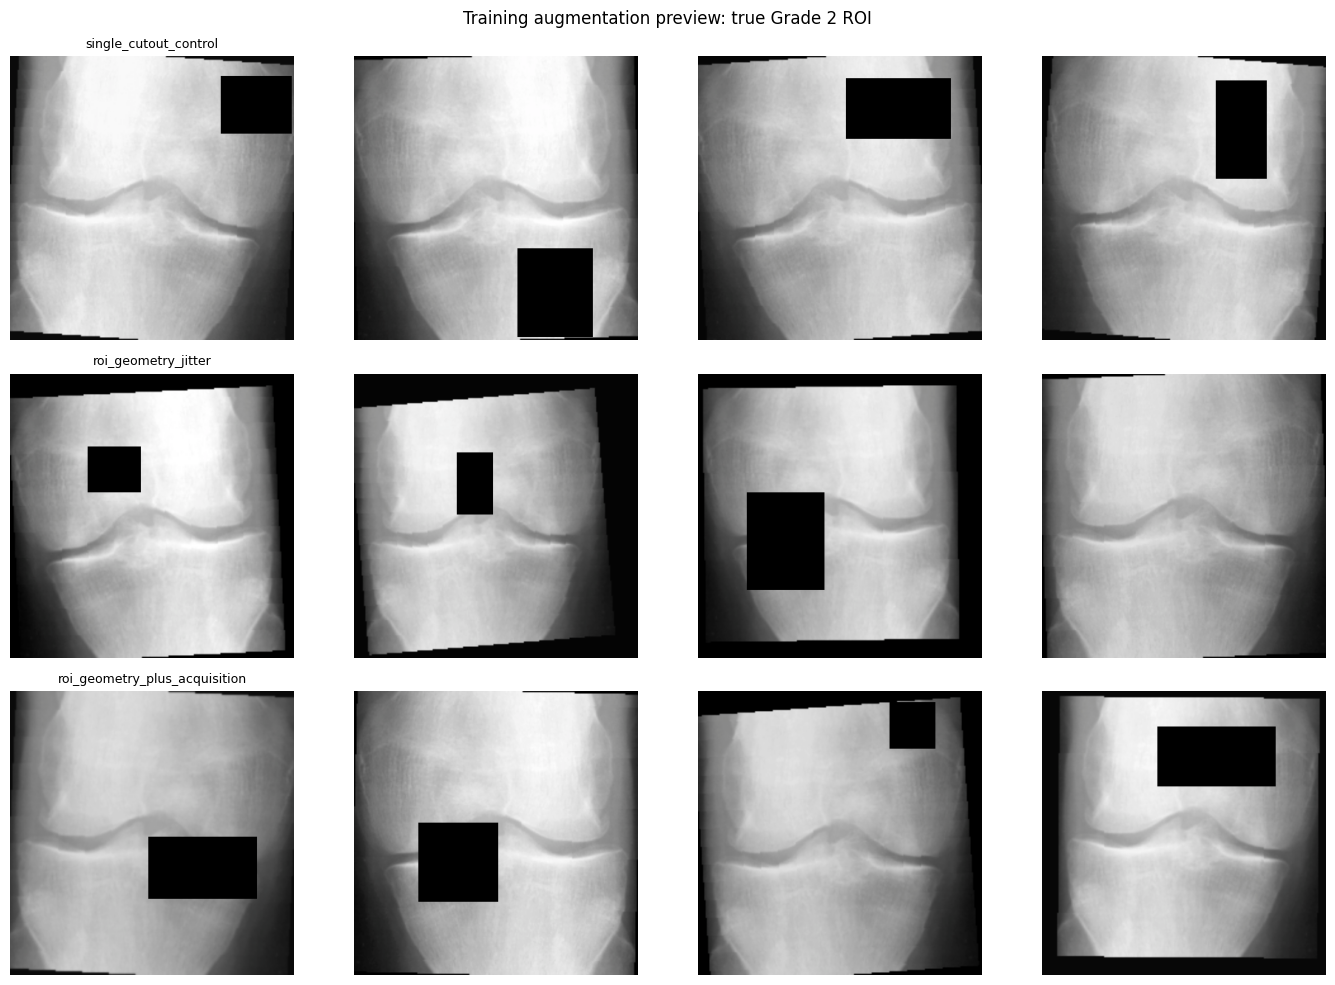

Saved: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-28_04-58-51_294354_UTC_roi_robustness_ablation/augmentation_preview.jpg


In [4]:
preview_index = next(
    index for index, label in enumerate(train_labels) if label == 2
)
preview_bgr = cv2.imread(train_paths[preview_index])
preview_rgb = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
figure, axes = plt.subplots(len(TrainingConfig.arms), 4, figsize=(14, 10))
for row_index, (arm_name, arm_spec) in enumerate(TrainingConfig.arms.items()):
    train_transform, _ = get_transforms(arm_spec)
    for column_index in range(4):
        tensor = train_transform(preview_rgb.copy())
        displayed = torch.clamp(tensor * std + mean, 0, 1).permute(1, 2, 0).numpy()
        axes[row_index, column_index].imshow(displayed)
        axes[row_index, column_index].axis('off')
        if column_index == 0:
            axes[row_index, column_index].set_title(arm_name, fontsize=9)
figure.suptitle('Training augmentation preview: true Grade 2 ROI')
figure.tight_layout()
preview_path = Path(TrainingConfig.run_root) / 'augmentation_preview.jpg'
figure.savefig(preview_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', preview_path)

## Standard DenseNet121 classifier and fixed training loop

The classifier head is standard global-average pooling plus a linear layer. Grad-CAM
is created later from `features.norm5`; it is not part of training.


In [5]:
class DenseNet121Classifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'densenet121',
            pretrained=pretrained,
            num_classes=TrainingConfig.num_classes,
            drop_rate=TrainingConfig.classifier_dropout,
        )
        self.use_amp = bool(TrainingConfig.use_amp and torch.cuda.is_available())
        self.scaler = torch.amp.GradScaler('cuda', enabled=self.use_amp)

    @property
    def classifier(self):
        return self.backbone.classifier

    @property
    def gradcam_target_layer(self):
        return self.backbone.features.norm5

    def forward(self, images):
        return self.backbone(images)

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.classifier.parameters():
            parameter.requires_grad = True

    def unfreeze_last_block(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        for name, module in self.backbone.named_modules():
            if 'denseblock3' in name or 'denseblock4' in name or 'norm5' in name:
                for parameter in module.parameters():
                    parameter.requires_grad = True
        for parameter in self.classifier.parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True


def evaluate(model, loader):
    model.eval()
    all_labels, all_predictions, all_probabilities = [], [], []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            # Match the Grad-CAM audit and production scoring precision.
            logits = model(images)
            loss = criterion(logits, labels)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += float(loss.item()) * labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(probabilities.argmax(1).cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    labels = np.asarray(all_labels)
    predictions = np.asarray(all_predictions)
    probabilities = np.asarray(all_probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=list(range(5)), average='macro', zero_division=0
    )
    one_hot = np.eye(5)[labels]
    try:
        macro_ap = average_precision_score(one_hot, probabilities, average='macro')
    except ValueError:
        macro_ap = float('nan')
    try:
        macro_auc = roc_auc_score(one_hot, probabilities, average='macro')
    except ValueError:
        macro_auc = float('nan')
    qwk = cohen_kappa_score(labels, predictions, weights='quadratic')
    grade1_recall = recall_score(labels == 1, predictions == 1, zero_division=0)
    return {
        'loss': total_loss / max(1, len(labels)),
        'accuracy': float(np.mean(labels == predictions)),
        'qwk': float(qwk),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
        'grade1_recall': float(grade1_recall),
        'macro_ap': float(macro_ap),
        'macro_auc': float(macro_auc),
        'labels': labels,
        'predictions': predictions,
        'probabilities': probabilities,
        'classification_report': classification_report(
            labels, predictions, labels=list(range(5)), zero_division=0
        ),
    }


def selection_score(metrics):
    return sum(
        TrainingConfig.selection_weights[name] * metrics[name]
        for name in TrainingConfig.selection_weights
    )


def build_loaders(arm_name, arm_spec):
    train_transform, val_transform = get_transforms(arm_spec)
    train_data = KaggleDataset(
        TrainingConfig.dataset_root, 'train', transform=train_transform,
        paths=train_paths, labels=train_labels,
    )
    val_data = KaggleDataset(
        TrainingConfig.dataset_root, 'val', transform=val_transform,
        paths=val_paths, labels=val_labels,
    )
    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=torch.Generator().manual_seed(TrainingConfig.seed),
    )
    loader_kwargs = {
        'num_workers': TrainingConfig.num_workers,
        'pin_memory': torch.cuda.is_available(),
        'persistent_workers': TrainingConfig.num_workers > 0,
    }
    train_loader = DataLoader(
        train_data, batch_size=TrainingConfig.batch_size, sampler=sampler,
        generator=torch.Generator().manual_seed(TrainingConfig.seed), **loader_kwargs
    )
    val_loader = DataLoader(
        val_data, batch_size=TrainingConfig.batch_size, shuffle=False, **loader_kwargs
    )
    return train_data, val_data, train_loader, val_loader


def train_one_epoch(model, loader, optimizer):
    model.train()
    criterion = nn.CrossEntropyLoss()
    total_loss, total, correct = 0.0, 0, 0
    for images, labels in tqdm.tqdm(loader, leave=False):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=model.use_amp):
            logits = model(images)
            loss = criterion(logits, labels)
        model.scaler.scale(loss).backward()
        model.scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        model.scaler.step(optimizer)
        model.scaler.update()
        total_loss += float(loss.item()) * labels.size(0)
        total += labels.size(0)
        correct += int((logits.argmax(1) == labels).sum().item())
    return total_loss / max(1, total), correct / max(1, total)


def save_checkpoint(path, model, optimizer, scheduler, arm_name, epoch, metrics, history):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'model_name': TrainingConfig.model_name,
        'architecture': TrainingConfig.architecture,
        'loss_type': 'ce',
        'run_timestamp': TrainingConfig.run_timestamp,
        'arm': arm_name,
        'validation_metrics': {key: value for key, value in metrics.items() if isinstance(value, (int, float))},
        'training_config': {
            'batch_size': TrainingConfig.batch_size,
            'image_size': TrainingConfig.image_size,
            'sampler_power': TrainingConfig.sampler_power,
            'stage_schedule': [TrainingConfig.stage1_epochs, TrainingConfig.stage2_epochs, TrainingConfig.stage3_epochs],
            'selection_weights': TrainingConfig.selection_weights,
            'orientation_policy': 'natural_no_inference_canonicalization',
            'preprocessing': 'CLAHE 1.25 -> SquarePad -> Resize 384',
            'arm': TrainingConfig.arms[arm_name],
        },
        'history': history,
    }
    torch.save(checkpoint, path)


def train_arm(arm_name, arm_spec):
    print(f'\n===== TRAINING {arm_name} =====')
    random.seed(TrainingConfig.seed)
    np.random.seed(TrainingConfig.seed)
    torch.manual_seed(TrainingConfig.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(TrainingConfig.seed)
    train_data, val_data, train_loader, val_loader = build_loaders(arm_name, arm_spec)
    arm_dir = Path(TrainingConfig.run_root) / arm_name
    arm_dir.mkdir(parents=True, exist_ok=True)
    model = DenseNet121Classifier(pretrained=TrainingConfig.pretrained).to(device)
    history = []
    stage2_path = arm_dir / 'stage2_best_model.pth'
    best_path = arm_dir / 'best_model.pth'
    best_stage2_score = -float('inf')
    best_stage3_score = -float('inf')
    best_epoch = None
    current_stage = None
    optimizer = scheduler = None
    total_epochs = TrainingConfig.stage1_epochs + TrainingConfig.stage2_epochs + TrainingConfig.stage3_epochs

    for epoch in range(total_epochs):
        if epoch < TrainingConfig.stage1_epochs:
            stage = 'stage1'
            if current_stage != stage:
                model.freeze_backbone()
                optimizer = optim.AdamW(model.classifier.parameters(), lr=TrainingConfig.lr_warmup, weight_decay=TrainingConfig.weight_decay)
                scheduler = None
                current_stage = stage
        elif epoch < TrainingConfig.stage1_epochs + TrainingConfig.stage2_epochs:
            stage = 'stage2'
            if current_stage != stage:
                model.unfreeze_last_block()
                head_ids = {id(parameter) for parameter in model.classifier.parameters()}
                backbone_parameters = [
                    parameter for parameter in model.backbone.parameters()
                    if parameter.requires_grad and id(parameter) not in head_ids
                ]
                optimizer = optim.AdamW([
                    {'params': backbone_parameters, 'lr': TrainingConfig.lr_coarse_backbone},
                    {'params': model.classifier.parameters(), 'lr': TrainingConfig.lr_coarse_head},
                ], weight_decay=TrainingConfig.weight_decay)
                scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TrainingConfig.stage2_epochs, eta_min=1e-7)
                current_stage = stage
        else:
            stage = 'stage3'
            if current_stage != stage:
                if stage2_path.exists():
                    checkpoint = torch.load(stage2_path, map_location=device, weights_only=False)
                    model.load_state_dict(checkpoint['model_state_dict'])
                model.unfreeze_all()
                optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_finetune, weight_decay=10 * TrainingConfig.weight_decay)
                scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TrainingConfig.stage3_epochs, eta_min=1e-7)
                current_stage = stage

        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer)
        metrics = evaluate(model, val_loader)
        score = selection_score(metrics)
        history.append({
            'epoch': epoch + 1,
            'stage': stage,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'selection_score': score,
            **{key: value for key, value in metrics.items() if isinstance(value, (int, float))},
        })
        if scheduler is not None:
            scheduler.step()
        print(
            f'{arm_name} | epoch {epoch + 1}/{total_epochs} | {stage} | '
            f'QWK={metrics["qwk"]:.4f} | F1={metrics["macro_f1"]:.4f} | '
            f'G1R={metrics["grade1_recall"]:.4f} | AP={metrics["macro_ap"]:.4f} | selection={score:.4f}'
        )
        if stage == 'stage2' and score > best_stage2_score:
            best_stage2_score = score
            torch.save({
                'model_state_dict': model.state_dict(),
                'validation_metrics': {key: value for key, value in metrics.items() if isinstance(value, (int, float))},
                'epoch': epoch + 1,
            }, stage2_path)
        if stage == 'stage3' and score > best_stage3_score:
            best_stage3_score = score
            best_epoch = epoch + 1
            save_checkpoint(best_path, model, optimizer, scheduler, arm_name, epoch + 1, metrics, history)

    if not best_path.exists():
        save_checkpoint(best_path, model, optimizer, scheduler, arm_name, total_epochs, metrics, history)
        best_epoch = total_epochs
    checkpoint_hash = hashlib.sha256(best_path.read_bytes()).hexdigest()
    manifest = {
        'arm': arm_name,
        'run_timestamp': TrainingConfig.run_timestamp,
        'checkpoint': str(best_path),
        'checkpoint_sha256': checkpoint_hash,
        'best_epoch': best_epoch,
        'architecture': TrainingConfig.architecture,
        'loss': 'ce',
        'sampler': 'full_inverse_frequency',
        'arm_config': arm_spec,
        'history': history,
    }
    (arm_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, default=float))
    return {
        'arm': arm_name,
        'checkpoint': str(best_path),
        'arm_dir': str(arm_dir),
        'best_epoch': best_epoch,
        'best_selection_score': best_stage3_score,
        'history': history,
    }

## Run all three arms

This is the long-running cell. Run every earlier cell first and inspect the saved
augmentation preview. Each arm writes its checkpoint and manifest immediately.
Completed arm folders remain available if the Colab runtime stops.

In [6]:
arm_results = {}
for arm_name, arm_spec in TrainingConfig.arms.items():
    arm_results[arm_name] = train_arm(arm_name, arm_spec)

with open(os.path.join(TrainingConfig.run_root, 'arm_results.json'), 'w') as handle:
    json.dump(arm_results, handle, indent=2, default=float)
print(json.dumps({
    name: {
        'best_epoch': result['best_epoch'],
        'best_selection_score': result['best_selection_score'],
        'checkpoint': result['checkpoint'],
    }
    for name, result in arm_results.items()
}, indent=2))



===== TRAINING single_cutout_control =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

single_cutout_control | epoch 1/30 | stage1 | QWK=0.2925 | F1=0.2516 | G1R=0.2484 | AP=0.2753 | selection=0.2753


...

roi_geometry_plus_acquisition | epoch 26/30 | stage3 | QWK=0.7950 | F1=0.6587 | G1R=0.4314 | AP=0.7344 | selection=0.7155


roi_geometry_plus_acquisition | epoch 27/30 | stage3 | QWK=0.7913 | F1=0.6613 | G1R=0.4444 | AP=0.7345 | selection=0.7156


roi_geometry_plus_acquisition | epoch 28/30 | stage3 | QWK=0.7894 | F1=0.6541 | G1R=0.4379 | AP=0.7317 | selection=0.7118


roi_geometry_plus_acquisition | epoch 29/30 | stage3 | QWK=0.8025 | F1=0.6594 | G1R=0.3922 | AP=0.7351 | selection=0.7156


roi_geometry_plus_acquisition | epoch 30/30 | stage3 | QWK=0.7903 | F1=0.6563 | G1R=0.4183 | AP=0.7358 | selection=0.7114
{
  "single_cutout_control": {
    "best_epoch": 26,
    "best_selection_score": 0.7390214970020624,
    "checkpoint": "/content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-28_04-58-51_294354_UTC_roi_robustness_ablation/single_cutout_control/best_model.pth"
  },
  "roi_geometry_jitter": {
    "best_epoch": 29,
    "best_selection_score": 0.7255425952970929,
    "checkpoint": "/content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-28_04-58-51_294354_UTC_roi_robustness_ablation/roi_geometry_jitter/best_model.pth"
  },
  "roi_geometry_plus_acquisition": {
    "best_epoch": 25,
    "best_selection_score": 0.7206810695959229,
    "checkpoint": "/content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-28_04-58-51_294354_UTC_roi_robustness_ablation/roi_geometry_plus_acquisition/best_model.pth"
  }
}


## Grad-CAM audit: identical validation cases for every arm

All 826 validation ROIs are audited with the same deterministic preprocessing.
The notebook exports every anatomy-gate failure, representative passing cases for
each grade, and predicted-vs-true class CAM pairs for misclassified examples.

In [7]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = model.gradcam_target_layer.register_forward_hook(self.capture)

    def capture(self, module, inputs, output):
        self.activations = output

    def capture_gradient(self, gradient):
        self.gradients = gradient

    def remove(self):
        self.handle.remove()

    def __call__(self, tensor, class_index=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None
        with torch.enable_grad():
            logits = self.model(tensor.detach().clone().requires_grad_(True))
            predicted = int(logits.argmax(1).item())
            target_class = predicted if class_index is None else int(class_index)
            if self.activations is None or not self.activations.requires_grad:
                raise RuntimeError('Could not capture Grad-CAM activation.')
            self.activations.register_hook(self.capture_gradient)
            logits[0, target_class].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=tensor.shape[-2:], mode='bilinear', align_corners=False)[0, 0]
        cam = cam.detach().cpu().numpy()
        cam /= max(float(cam.max()), 1e-8)
        return logits.detach(), predicted, target_class, cam


def prepare_cam_input(path):
    image_bgr = cv2.imread(path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    processed_rgb = np.asarray(transforms.Compose([
        OpenCVCLAHE(), SquarePadOpenCV(), transforms.ToPILImage(),
        transforms.Resize((TrainingConfig.image_size, TrainingConfig.image_size)),
    ])(image_rgb))
    tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])(processed_rgb).unsqueeze(0).to(device)
    return image_rgb, processed_rgb, tensor


def cam_metrics(cam):
    height, width = cam.shape
    joint = np.zeros_like(cam, dtype=bool)
    joint[int(.28 * height):int(.72 * height), int(.06 * width):int(.94 * width)] = True
    border = np.ones_like(cam, dtype=bool)
    border[int(.08 * height):int(.92 * height), int(.08 * width):int(.92 * width)] = False
    lower = np.zeros_like(cam, dtype=bool)
    lower[int(.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        'joint_energy': float(cam[joint].sum() / total),
        'border_energy': float(cam[border].sum() / total),
        'lower_tibia_energy': float(cam[lower].sum() / total),
        'peak_inside_joint': bool(joint[peak]),
    }


def cam_failures(metrics):
    reasons = []
    if metrics['joint_energy'] < TrainingConfig.min_joint_energy:
        reasons.append('low_joint_energy')
    if metrics['border_energy'] > TrainingConfig.max_border_energy:
        reasons.append('high_border_energy')
    if metrics['lower_tibia_energy'] > TrainingConfig.max_lower_tibia_energy:
        reasons.append('high_lower_tibia_energy')
    if not metrics['peak_inside_joint']:
        reasons.append('peak_outside_joint')
    return reasons


def cam_overlay(processed, cam):
    heatmap = cv2.applyColorMap(np.uint8(np.clip(cam, 0, 1) * 255), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(processed, .60, heatmap, .40, 0)


def save_cam_comparison(original, processed, cam, row, path):
    overlay = cam_overlay(processed, cam)
    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title(f'Original ROI | true G{row["true_grade"]}')
    axes[1].imshow(processed)
    axes[1].set_title('CLAHE 1.25 -> pad -> 384')
    axes[2].imshow(overlay)
    axes[2].set_title(f'Grad-CAM predicted G{row["predicted_grade"]}')
    for axis in axes:
        axis.axis('off')
    figure.suptitle(
        f'joint={row["joint_energy"]:.3f} border={row["border_energy"]:.3f} '
        f'lower={row["lower_tibia_energy"]:.3f} | {row["failure_reasons"] or "pass"}',
        fontsize=10,
    )
    figure.tight_layout()
    figure.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(figure)



def save_true_predicted_cam_pair(original, processed, predicted_cam, true_cam, row, path):
    figure, axes = plt.subplots(1, 4, figsize=(19, 5))
    axes[0].imshow(original)
    axes[0].set_title(f'Original ROI | true G{row["true_grade"]}')
    axes[1].imshow(processed)
    axes[1].set_title('Exact deterministic input')
    axes[2].imshow(cam_overlay(processed, predicted_cam))
    axes[2].set_title(f'Predicted-class CAM | G{row["predicted_grade"]}')
    axes[3].imshow(cam_overlay(processed, true_cam))
    axes[3].set_title(f'True-class CAM | G{row["true_grade"]}')
    for axis in axes:
        axis.axis('off')
    figure.suptitle(
        f'Wrong prediction: true G{row["true_grade"]} -> predicted G{row["predicted_grade"]} '
        f'| confidence={row["confidence"]:.3f}',
        fontsize=11,
    )
    figure.tight_layout()
    figure.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(figure)


audit_indices = []
for grade in range(TrainingConfig.num_classes):
    candidates = [index for index, label in enumerate(val_labels) if label == grade]
    limit = TrainingConfig.cam_cases_per_grade
    audit_indices.extend(candidates if limit is None else candidates[:limit])
audit_indices = sorted(set(audit_indices))
print('Shared CAM audit cases:', len(audit_indices))

audit_summary = {}
for arm_name, arm_result in arm_results.items():
    arm_dir = Path(arm_result['arm_dir'])
    audit_dir = arm_dir / 'gradcam_audit'
    failed_dir = audit_dir / 'failed'
    pass_dir = audit_dir / 'representative_passes'
    pair_dir = audit_dir / 'misclassified_true_vs_predicted'
    audit_dir.mkdir(exist_ok=True)
    failed_dir.mkdir(exist_ok=True)
    pass_dir.mkdir(exist_ok=True)
    pair_dir.mkdir(exist_ok=True)
    train_transform, val_transform = get_transforms(TrainingConfig.arms[arm_name])
    model = DenseNet121Classifier(pretrained=False).to(device)
    checkpoint = torch.load(arm_result['checkpoint'], map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    gradcam = GradCAM(model)
    rows = []
    failed_paths = []
    pass_export_counts = Counter()
    pair_export_counts = Counter()
    for audit_number, index in enumerate(tqdm.tqdm(audit_indices, desc=f'CAM {arm_name}')):
        original, processed, tensor = prepare_cam_input(val_paths[index])
        logits, predicted, _, cam = gradcam(tensor)
        probabilities = F.softmax(logits.float(), dim=1)[0]
        metrics = cam_metrics(cam)
        reasons = cam_failures(metrics)
        row = {
            'dataset_index': index,
            'filename': os.path.basename(val_paths[index]),
            'true_grade': int(val_labels[index]),
            'predicted_grade': predicted,
            'confidence': float(probabilities[predicted].item()),
            'correct': int(predicted == int(val_labels[index])),
            'failure_reasons': ';'.join(reasons),
            **metrics,
        }
        rows.append(row)
        if reasons:
            figure_path = failed_dir / f'{audit_number:04d}_true_G{row["true_grade"]}_pred_G{predicted}.jpg'
            save_cam_comparison(original, processed, cam, row, figure_path)
            failed_paths.append(str(figure_path))
        elif pass_export_counts[row['true_grade']] < TrainingConfig.representative_passes_per_grade:
            figure_path = pass_dir / f'{audit_number:04d}_true_G{row["true_grade"]}_pred_G{predicted}.jpg'
            save_cam_comparison(original, processed, cam, row, figure_path)
            pass_export_counts[row['true_grade']] += 1
        if predicted != row['true_grade'] and pair_export_counts[row['true_grade']] < TrainingConfig.misclassified_pairs_per_grade:
            _, _, _, true_cam = gradcam(tensor, class_index=row['true_grade'])
            pair_path = pair_dir / f'{audit_number:04d}_true_G{row["true_grade"]}_pred_G{predicted}.jpg'
            save_true_predicted_cam_pair(original, processed, cam, true_cam, row, pair_path)
            pair_export_counts[row['true_grade']] += 1
    gradcam.remove()
    with open(audit_dir / 'all_cases.csv', 'w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    failed_rows = [row for row in rows if row['failure_reasons']]
    with open(audit_dir / 'failed_cases.csv', 'w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(failed_rows)
    summary = {
        'arm': arm_name,
        'cases': len(rows),
        'gate_passes': len(rows) - len(failed_rows),
        'gate_failures': len(failed_rows),
        'gate_failure_rate': len(failed_rows) / max(1, len(rows)),
        'failure_reasons': dict(Counter(reason for row in failed_rows for reason in row['failure_reasons'].split(';') if reason)),
        'failed_by_true_grade': dict(Counter(row['true_grade'] for row in failed_rows)),
        'mean_joint_energy': float(np.mean([row['joint_energy'] for row in rows])),
        'mean_border_energy': float(np.mean([row['border_energy'] for row in rows])),
        'mean_lower_tibia_energy': float(np.mean([row['lower_tibia_energy'] for row in rows])),
        'representative_pass_exports': dict(pass_export_counts),
        'misclassified_pair_exports': dict(pair_export_counts),
        'thresholds': {
            'minimum_joint_energy': TrainingConfig.min_joint_energy,
            'maximum_border_energy': TrainingConfig.max_border_energy,
            'maximum_lower_tibia_energy': TrainingConfig.max_lower_tibia_energy,
        },
    }
    (audit_dir / 'summary.json').write_text(json.dumps(summary, indent=2))
    audit_summary[arm_name] = summary

with open(os.path.join(TrainingConfig.run_root, 'gradcam_comparison_summary.json'), 'w') as handle:
    json.dump(audit_summary, handle, indent=2)
print(json.dumps(audit_summary, indent=2))

Shared CAM audit cases: 826


CAM single_cutout_control:   0%|          | 0/826 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
CAM roi_geometry_plus_acquisition: 100%|██████████| 826/826 [01:24<00:00,  9.74it/s]

{
  "single_cutout_control": {
    "arm": "single_cutout_control",
    "cases": 826,
    "gate_passes": 808,
    "gate_failures": 18,
    "gate_failure_rate": 0.021791767554479417,
    "failure_reasons": {
      "high_border_energy": 4,
      "high_lower_tibia_energy": 14
    },
    "failed_by_true_grade": {
      "0": 1,
      "1": 5,
      "2": 9,
      "3": 2,
      "4": 1
    },
    "mean_joint_energy": 0.813682332165882,
    "mean_border_energy": 0.12663085815061526,
    "mean_lower_tibia_energy": 0.09487692999527238,
    "representative_pass_exports": {
      "0": 2,
      "1": 2,
      "2": 2,
      "3": 2,
      "4": 2
    },
    "misclassified_pair_exports": {
      "0": 10,
      "1": 10,
      "2": 10,
      "3": 10,
      "4": 3
    },
    "thresholds": {
      "minimum_joint_energy": 0.55,
      "maximum_border_energy": 0.25,
      "maximum_lower_tibia_energy": 0.25
    }
  },
  "roi_geometry_jitter": {
    "arm": "roi_geometry_jitter",
    "cases": 826,
    "gate_passes":

## Arm comparison and promotion decision

The report distinguishes the validation metric winner from a promotion candidate.
An arm is eligible only when macro F1, Grade-1 recall, and CAM failure rate satisfy
the fixed safeguards. External production-ROI comparison remains mandatory.

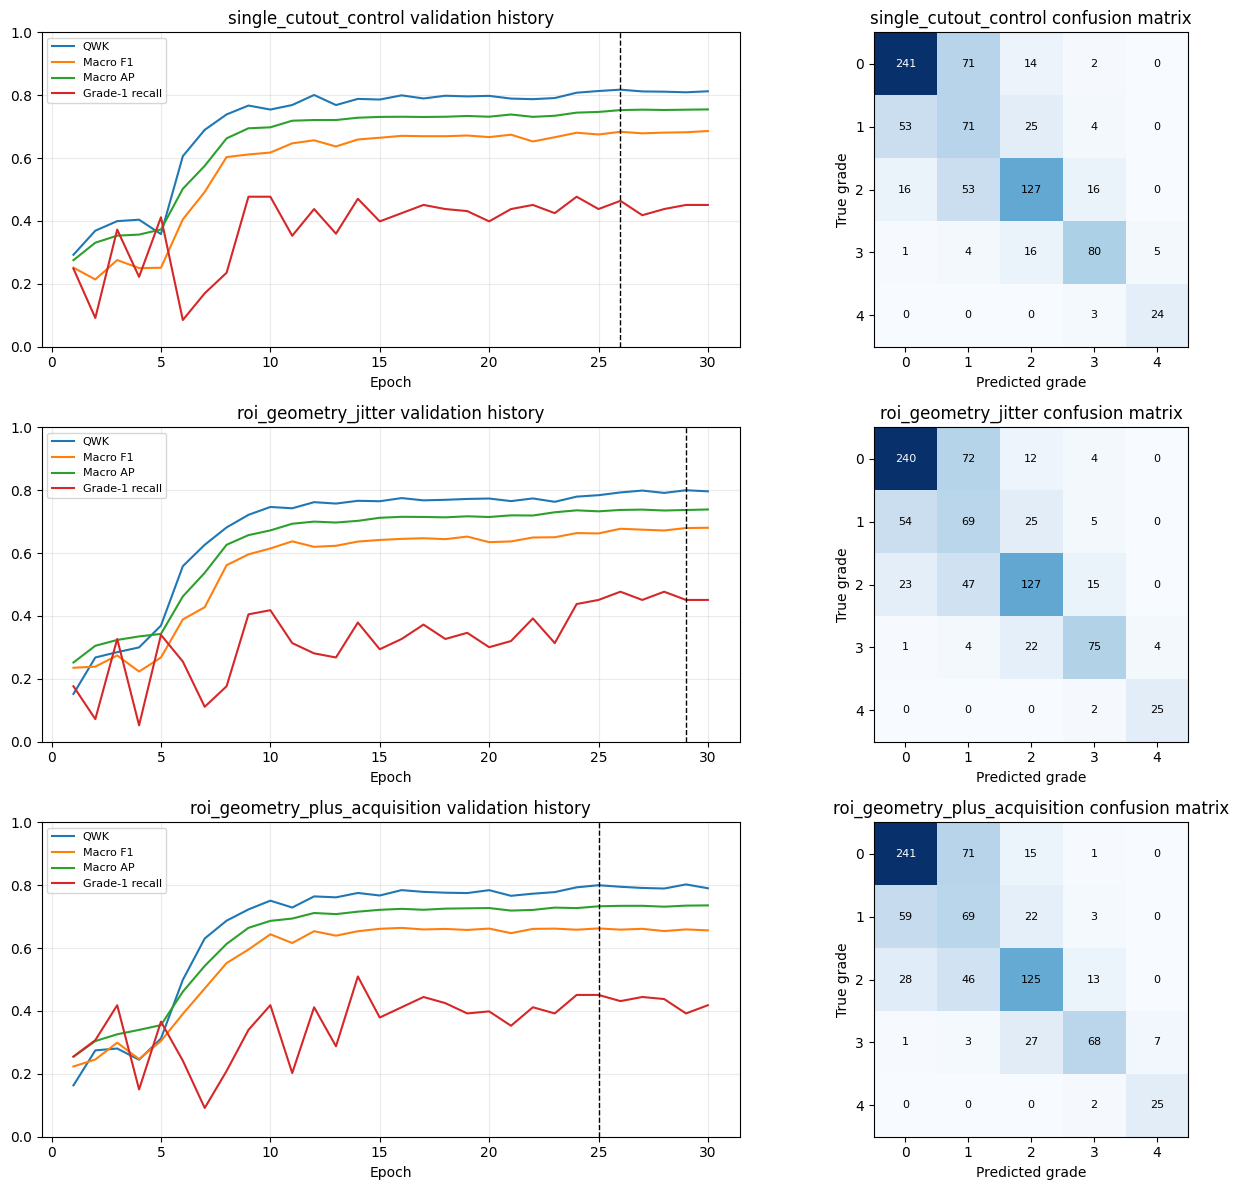

# DenseNet121 Production-ROI Robustness Ablation - 2026-07-28_04-58-51_294354_UTC

| Arm | Best epoch | QWK | Macro F1 | AP | G1 recall | CAM fail | Joint energy | Border energy | Eligible |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | --- |
| single_cutout_control | 26 | 0.8177 | 0.6836 | 0.7526 | 0.4641 | 2.18% | 0.8137 | 0.1266 | no |
| roi_geometry_jitter | 29 | 0.7999 | 0.6797 | 0.7371 | 0.4510 | 0.85% | 0.8315 | 0.1212 | no |
| roi_geometry_plus_acquisition | 25 | 0.8000 | 0.6625 | 0.7329 | 0.4510 | 1.09% | 0.8379 | 0.1103 | no |

Validation metric winner: `single_cutout_control`.
Promotion candidate: none; keep the current production checkpoint.

Eligibility requires macro F1 >= 0.68, Grade-1 recall >= 0.48, and CAM failure <= 3.00%.

Combined curves and confusion matrices: `training_curves_and_confusion_matrices.png`.
Each arm directory contains `classification_report.txt`, `confusion_matrix.csv`, `gradcam_audit/failed/`, `gradcam_audit/representative_passes/

In [8]:
comparison = []
classification_reports = {}
confusion_matrices = {}
for arm_name, result in arm_results.items():
    history = result['history']
    best = next(
        row for row in history
        if row['epoch'] == result['best_epoch'] and row['stage'] == 'stage3'
    )
    cam_failure_rate = audit_summary[arm_name]['gate_failure_rate']
    promotion_eligible = (
        best['macro_f1'] >= TrainingConfig.minimum_promotion_macro_f1
        and best['grade1_recall'] >= TrainingConfig.minimum_promotion_grade1_recall
        and cam_failure_rate <= TrainingConfig.maximum_promotion_cam_failure_rate
    )
    audit_csv = Path(result['arm_dir']) / 'gradcam_audit' / 'all_cases.csv'
    with open(audit_csv, newline='') as handle:
        audit_rows = list(csv.DictReader(handle))
    audit_labels = [int(row['true_grade']) for row in audit_rows]
    audit_predictions = [int(row['predicted_grade']) for row in audit_rows]
    class_report_text = classification_report(
        audit_labels,
        audit_predictions,
        labels=list(range(TrainingConfig.num_classes)),
        digits=4,
        zero_division=0,
    )
    class_report_dict = classification_report(
        audit_labels,
        audit_predictions,
        labels=list(range(TrainingConfig.num_classes)),
        output_dict=True,
        zero_division=0,
    )
    matrix = confusion_matrix(
        audit_labels,
        audit_predictions,
        labels=list(range(TrainingConfig.num_classes)),
    )
    classification_reports[arm_name] = class_report_dict
    confusion_matrices[arm_name] = matrix
    arm_dir = Path(result['arm_dir'])
    (arm_dir / 'classification_report.txt').write_text(class_report_text)
    np.savetxt(
        arm_dir / 'confusion_matrix.csv',
        matrix,
        delimiter=',',
        fmt='%d',
        header='pred_G0,pred_G1,pred_G2,pred_G3,pred_G4',
        comments='',
    )
    comparison.append({
        'arm': arm_name,
        'best_epoch': result['best_epoch'],
        'selection_score': result['best_selection_score'],
        'qwk': best['qwk'],
        'macro_f1': best['macro_f1'],
        'macro_ap': best['macro_ap'],
        'grade1_recall': best['grade1_recall'],
        'cam_failure_rate': cam_failure_rate,
        'mean_joint_energy': audit_summary[arm_name]['mean_joint_energy'],
        'mean_border_energy': audit_summary[arm_name]['mean_border_energy'],
        'promotion_eligible': promotion_eligible,
        'checkpoint': result['checkpoint'],
    })
comparison.sort(key=lambda row: row['selection_score'], reverse=True)
with open(os.path.join(TrainingConfig.run_root, 'arm_comparison.csv'), 'w', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(comparison[0]))
    writer.writeheader()
    writer.writerows(comparison)

figure, axes = plt.subplots(len(comparison), 2, figsize=(14, 4 * len(comparison)))
for row_index, row in enumerate(comparison):
    history = arm_results[row['arm']]['history']
    epochs = [item['epoch'] for item in history]
    metric_axis = axes[row_index, 0]
    for metric_name, label in [
        ('qwk', 'QWK'),
        ('macro_f1', 'Macro F1'),
        ('macro_ap', 'Macro AP'),
        ('grade1_recall', 'Grade-1 recall'),
    ]:
        metric_axis.plot(
            epochs,
            [item[metric_name] for item in history],
            label=label,
        )
    metric_axis.axvline(row['best_epoch'], color='black', linestyle='--', linewidth=1)
    metric_axis.set_title(f"{row['arm']} validation history")
    metric_axis.set_xlabel('Epoch')
    metric_axis.set_ylim(0, 1)
    metric_axis.grid(alpha=0.25)
    metric_axis.legend(fontsize=8)

    matrix_axis = axes[row_index, 1]
    matrix = confusion_matrices[row['arm']]
    matrix_axis.imshow(matrix, cmap='Blues')
    matrix_axis.set_title(f"{row['arm']} confusion matrix")
    matrix_axis.set_xlabel('Predicted grade')
    matrix_axis.set_ylabel('True grade')
    matrix_axis.set_xticks(range(TrainingConfig.num_classes))
    matrix_axis.set_yticks(range(TrainingConfig.num_classes))
    for true_grade in range(TrainingConfig.num_classes):
        for predicted_grade in range(TrainingConfig.num_classes):
            value = int(matrix[true_grade, predicted_grade])
            color = 'white' if value > matrix.max() * 0.55 else 'black'
            matrix_axis.text(
                predicted_grade,
                true_grade,
                str(value),
                ha='center',
                va='center',
                color=color,
                fontsize=8,
            )
figure.tight_layout()
summary_figure_path = Path(TrainingConfig.run_root) / 'training_curves_and_confusion_matrices.png'
figure.savefig(summary_figure_path, dpi=160, bbox_inches='tight')
plt.show()

eligible = [row for row in comparison if row['promotion_eligible']]
promotion_candidate = eligible[0]['arm'] if eligible else None
report = [
    f'# DenseNet121 Production-ROI Robustness Ablation - {TrainingConfig.run_timestamp}',
    '',
    '| Arm | Best epoch | QWK | Macro F1 | AP | G1 recall | CAM fail | Joint energy | Border energy | Eligible |',
    '| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | --- |',
]
for row in comparison:
    report.append(
        f"| {row['arm']} | {row['best_epoch']} | {row['qwk']:.4f} | "
        f"{row['macro_f1']:.4f} | {row['macro_ap']:.4f} | "
        f"{row['grade1_recall']:.4f} | {row['cam_failure_rate']:.2%} | "
        f"{row['mean_joint_energy']:.4f} | {row['mean_border_energy']:.4f} | "
        f"{'yes' if row['promotion_eligible'] else 'no'} |"
    )
report.extend([
    '',
    f"Validation metric winner: `{comparison[0]['arm']}`.",
    f"Promotion candidate: `{promotion_candidate}`." if promotion_candidate else 'Promotion candidate: none; keep the current production checkpoint.',
    '',
    'Eligibility requires macro F1 >= '
    f'{TrainingConfig.minimum_promotion_macro_f1:.2f}, Grade-1 recall >= '
    f'{TrainingConfig.minimum_promotion_grade1_recall:.2f}, and CAM failure <= '
    f'{TrainingConfig.maximum_promotion_cam_failure_rate:.2%}.',
    '',
    'Combined curves and confusion matrices: `training_curves_and_confusion_matrices.png`.',
    'Each arm directory contains `classification_report.txt`, `confusion_matrix.csv`, '
    '`gradcam_audit/failed/`, `gradcam_audit/representative_passes/`, and '
    '`gradcam_audit/misclassified_true_vs_predicted/`.',
    '',
    'Do not deploy from this validation result alone. Compare the candidate and current checkpoint on identical production YOLO crops, then evaluate once on a newly locked labeled holdout.',
])
(Path(TrainingConfig.run_root) / 'report.md').write_text('\n'.join(report) + '\n')
with open(Path(TrainingConfig.run_root) / 'experiment_summary.json', 'w') as handle:
    json.dump({
        'run_timestamp': TrainingConfig.run_timestamp,
        'metric_winner': comparison[0]['arm'],
        'promotion_candidate': promotion_candidate,
        'selection_weights': TrainingConfig.selection_weights,
        'promotion_thresholds': {
            'minimum_macro_f1': TrainingConfig.minimum_promotion_macro_f1,
            'minimum_grade1_recall': TrainingConfig.minimum_promotion_grade1_recall,
            'maximum_cam_failure_rate': TrainingConfig.maximum_promotion_cam_failure_rate,
        },
        'arms': comparison,
        'classification_reports': classification_reports,
        'confusion_matrices': {
            arm_name: matrix.tolist()
            for arm_name, matrix in confusion_matrices.items()
        },
    }, handle, indent=2)
print('\n'.join(report))